# L08 Clustering Demo
Step-by-step visualization of k-means, k-means++, elbow method, and clustering metrics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             silhouette_score, fowlkes_mallows_score)
from sklearn.metrics.cluster import contingency_matrix
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

---
## 1. K-Means Step-by-Step
We manually implement k-means and visualize **each assign + update step**.

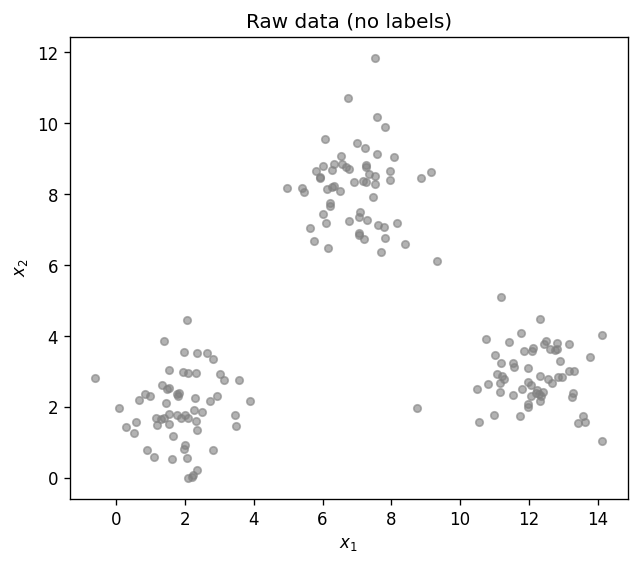

In [16]:
COLORS = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12", "#9b59b6"]
rng = np.random.RandomState(42)

# Generate 2D data with 3 clusters
true_centers = np.array([[2, 2], [7, 8], [12, 3]])
K = len(true_centers)
n_per = 60
X = np.vstack([rng.randn(n_per, 2) * 1.0 + c for c in true_centers])
rng.shuffle(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', s=20, alpha=0.6)
plt.title('Raw data (no labels)')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.show()

### Step 0: Random Initialization

Initial centers:
  Center 1: (11.02, 3.46)
  Center 2: (7.23, 9.31)
  Center 3: (6.01, 7.43)


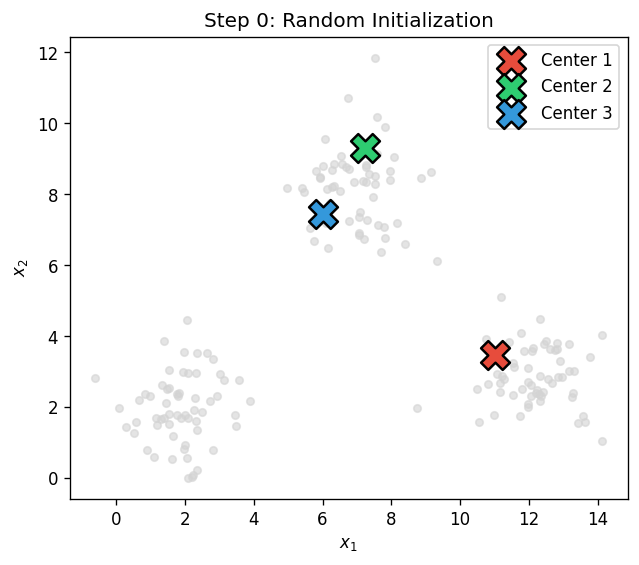

In [29]:
# Pick K random data points as initial centers
# idx = rng.choice(len(X), K, replace=False)
idx = [0,1,2]
centers = X[idx].copy()

print("Initial centers:")
for k in range(K):
    print(f"  Center {k+1}: ({centers[k, 0]:.2f}, {centers[k, 1]:.2f})")

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c='lightgray', s=20, alpha=0.6)
for k in range(K):
    plt.scatter(*centers[k], c=COLORS[k], s=300, marker='X',
               edgecolors='black', linewidths=1.5, zorder=5, label=f'Center {k+1}')
plt.title('Step 0: Random Initialization')
plt.legend(); plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.show()

### Run k-means iterations (Assign → Update → repeat)

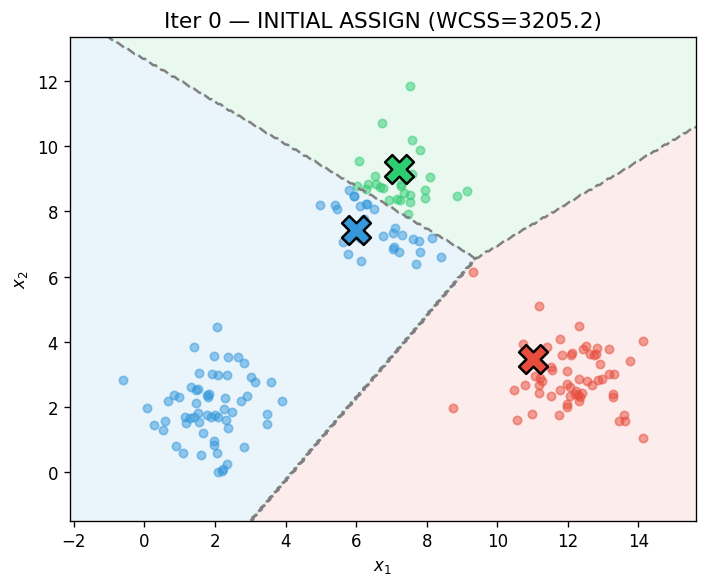

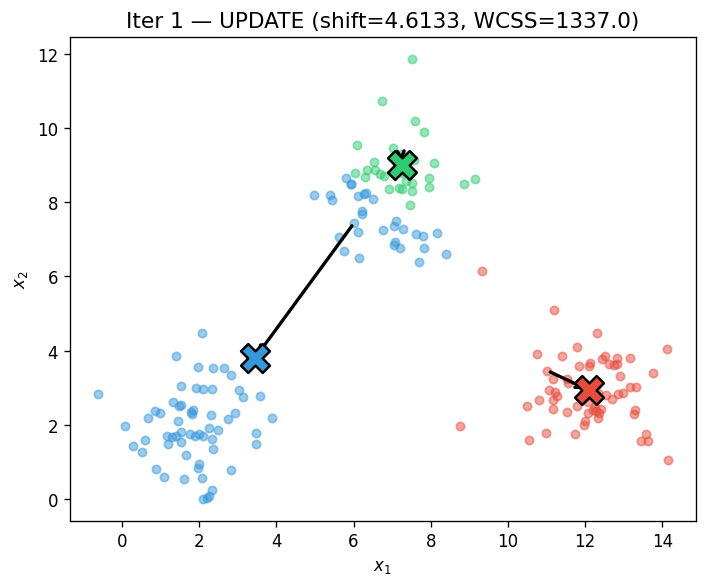

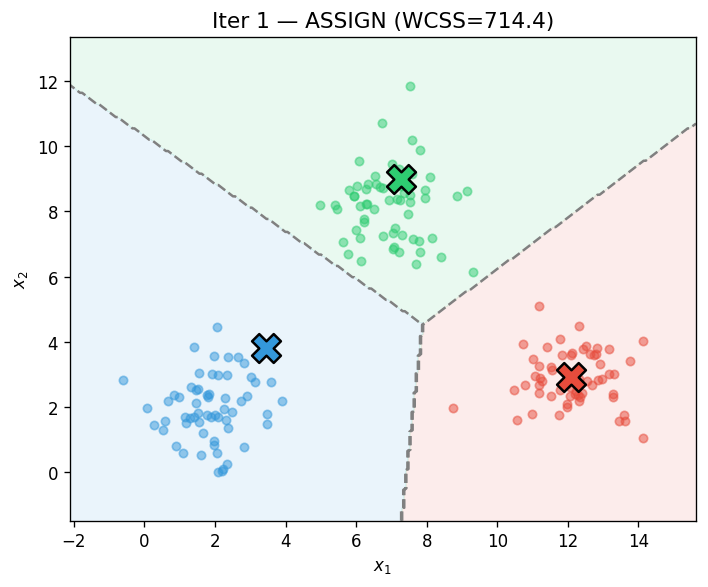

  Centers moved by 4.613296



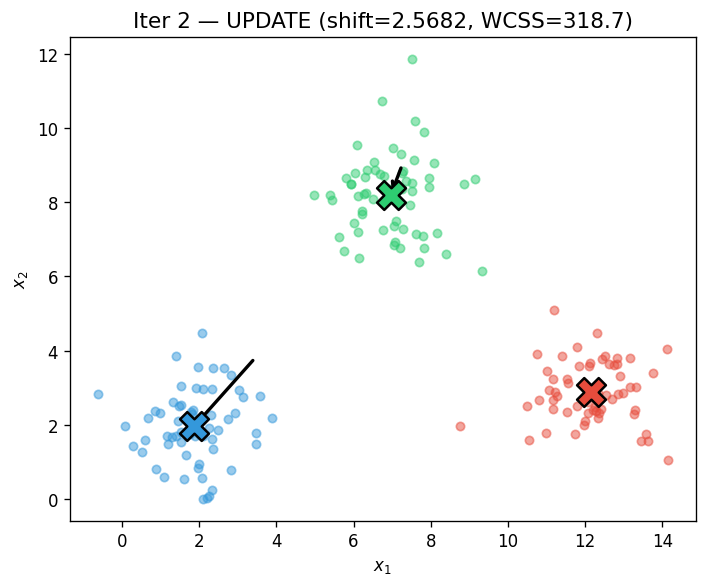

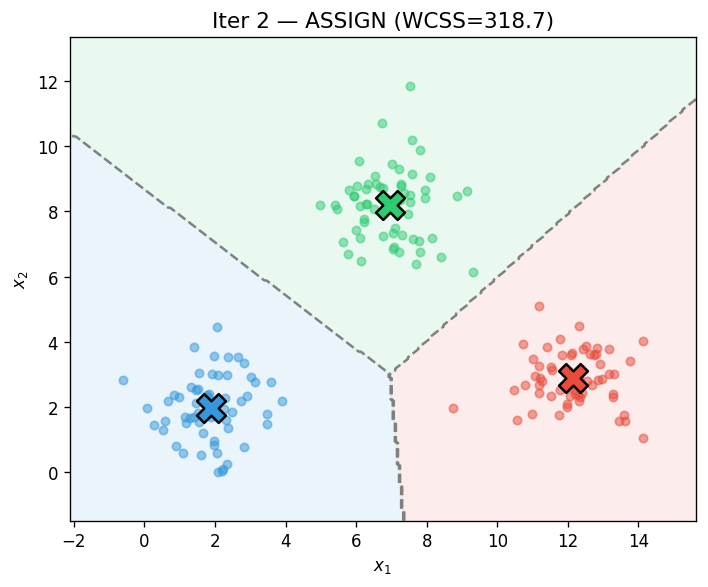

  Centers moved by 2.568172



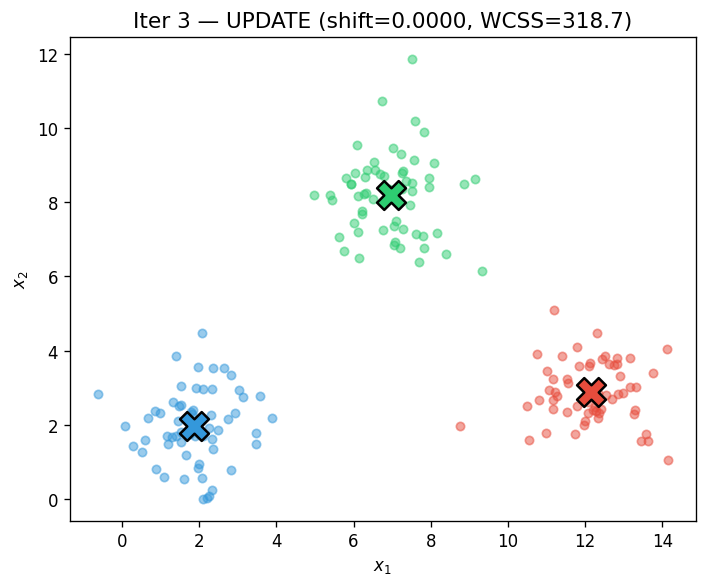

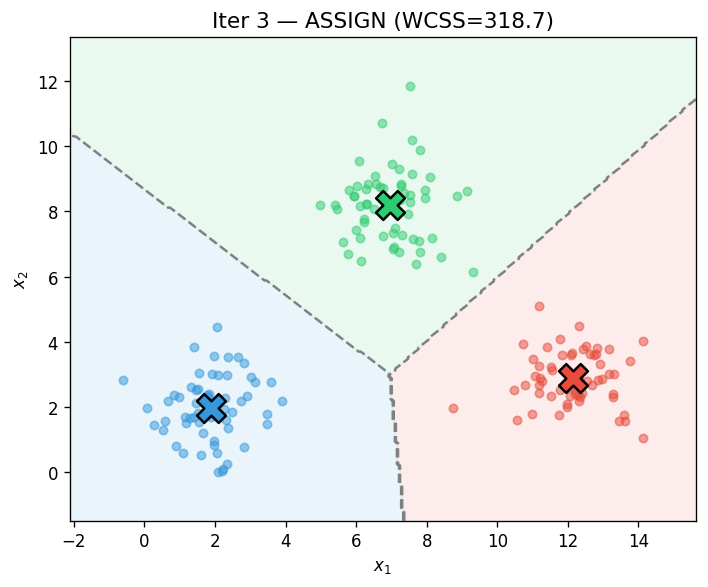

  Centers moved by 0.000000
  ✓ Converged at iteration 3!


In [30]:
def compute_wcss(X, labels, centers, K):
    return sum(np.sum((X[labels == k] - centers[k]) ** 2) for k in range(K))

def plot_decision_boundary(ax, centers, X, colors, K):
    """Draw Voronoi-style decision boundaries on the axes."""
    from matplotlib.colors import ListedColormap
    x_min, x_max = X[:, 0].min() - 1.5, X[:, 0].max() + 1.5
    y_min, y_max = X[:, 1].min() - 1.5, X[:, 1].max() + 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    dists_grid = np.linalg.norm(grid[:, None] - centers[None], axis=2)
    grid_labels = dists_grid.argmin(axis=1).reshape(xx.shape)
    cmap = ListedColormap(colors[:K])
    ax.contourf(xx, yy, grid_labels, levels=np.arange(K + 1) - 0.5,
                cmap=cmap, alpha=0.10)
    ax.contour(xx, yy, grid_labels, levels=np.arange(K - 1) + 0.5,
               colors='gray', linewidths=1.5, linestyles='--')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

def plot_kmeans_step(ax, X, labels, centers, colors, K,
                     old_centers=None, show_boundary=False):
    """Plot one k-means snapshot. Optionally draw boundaries and arrows."""
    if show_boundary:
        plot_decision_boundary(ax, centers, X, colors, K)
    for k in range(K):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], s=25, alpha=0.5)
    for k in range(K):
        ax.scatter(*centers[k], c=colors[k], s=300, marker='X',
                   edgecolors='black', linewidths=1.5, zorder=5)
        if old_centers is not None:
            ax.annotate('', xy=centers[k], xytext=old_centers[k],
                        arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# === STEP 0: initial assignment with random centers ===
dists = np.linalg.norm(X[:, None] - centers[None], axis=2)
labels = dists.argmin(axis=1)
wcss = compute_wcss(X, labels, centers, K)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
plot_kmeans_step(ax, X, labels, centers, COLORS, K, show_boundary=True)
ax.set_title(f'Iter 0 — INITIAL ASSIGN (WCSS={wcss:.1f})', fontsize=13)
plt.tight_layout()
plt.show()
print()

for t in range(1, 7):
    # === UPDATE STEP: move centers to cluster means ===
    old_centers = centers.copy()
    for k in range(K):
        centers[k] = X[labels == k].mean(axis=0)
    shift = np.linalg.norm(centers - old_centers)
    wcss_update = compute_wcss(X, labels, centers, K)

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    plot_kmeans_step(ax, X, labels, centers, COLORS, K,
                     old_centers=old_centers, show_boundary=False)
    ax.set_title(f'Iter {t} — UPDATE (shift={shift:.4f}, WCSS={wcss_update:.1f})', fontsize=13)
    plt.tight_layout()
    plt.show()

    # === ASSIGN STEP: reassign labels based on new centers ===
    dists = np.linalg.norm(X[:, None] - centers[None], axis=2)
    labels = dists.argmin(axis=1)
    wcss_assign = compute_wcss(X, labels, centers, K)

    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    plot_kmeans_step(ax, X, labels, centers, COLORS, K, show_boundary=True)
    ax.set_title(f'Iter {t} — ASSIGN (WCSS={wcss_assign:.1f})', fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f'  Centers moved by {shift:.6f}')
    if shift < 1e-4:
        print(f'  ✓ Converged at iteration {t}!')
        break
    print()

---
## 2. K-Means++ Initialization Step-by-Step
At each step we show:
- The **distance to nearest center** for every point
- The **D² probability** used to sample the next center
- Which point gets selected

In [5]:
rng_pp = np.random.RandomState(0)

# 4-cluster data for a richer demo
true_centers_4 = np.array([[2, 2], [7, 8], [12, 3], [1, 9]])
K4 = len(true_centers_4)
X4 = np.vstack([rng_pp.randn(60, 2) * 1.0 + c for c in true_centers_4])
rng_pp.shuffle(X4)
N4 = len(X4)

Step 1: Pick center 1 uniformly at random → point 79  (10.16, 2.52)


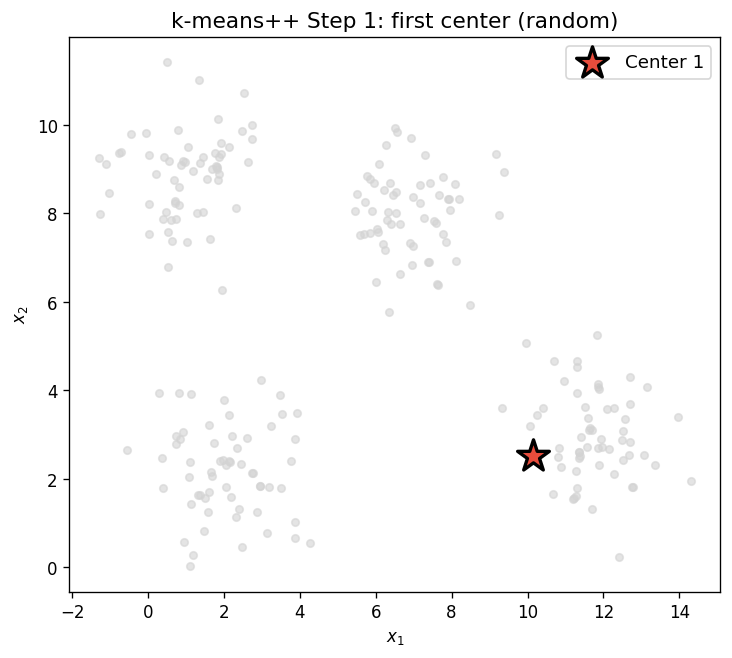

In [6]:
chosen_idx = []  # indices of chosen centers

# Step 1: pick first center uniformly at random
first = rng_pp.randint(N4)
chosen_idx.append(first)

print(f"Step 1: Pick center 1 uniformly at random → point {first}  ({X4[first, 0]:.2f}, {X4[first, 1]:.2f})")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X4[:, 0], X4[:, 1], c='lightgray', s=20, alpha=0.6)
ax.scatter(*X4[first], c=COLORS[0], s=400, marker='*',
           edgecolors='black', linewidths=2, zorder=6, label='Center 1')
ax.set_title('k-means++ Step 1: first center (random)', fontsize=13)
ax.legend(fontsize=11); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.show()

Step 2: D² sampling → pick center 2 = point 107  (6.56, 9.85)


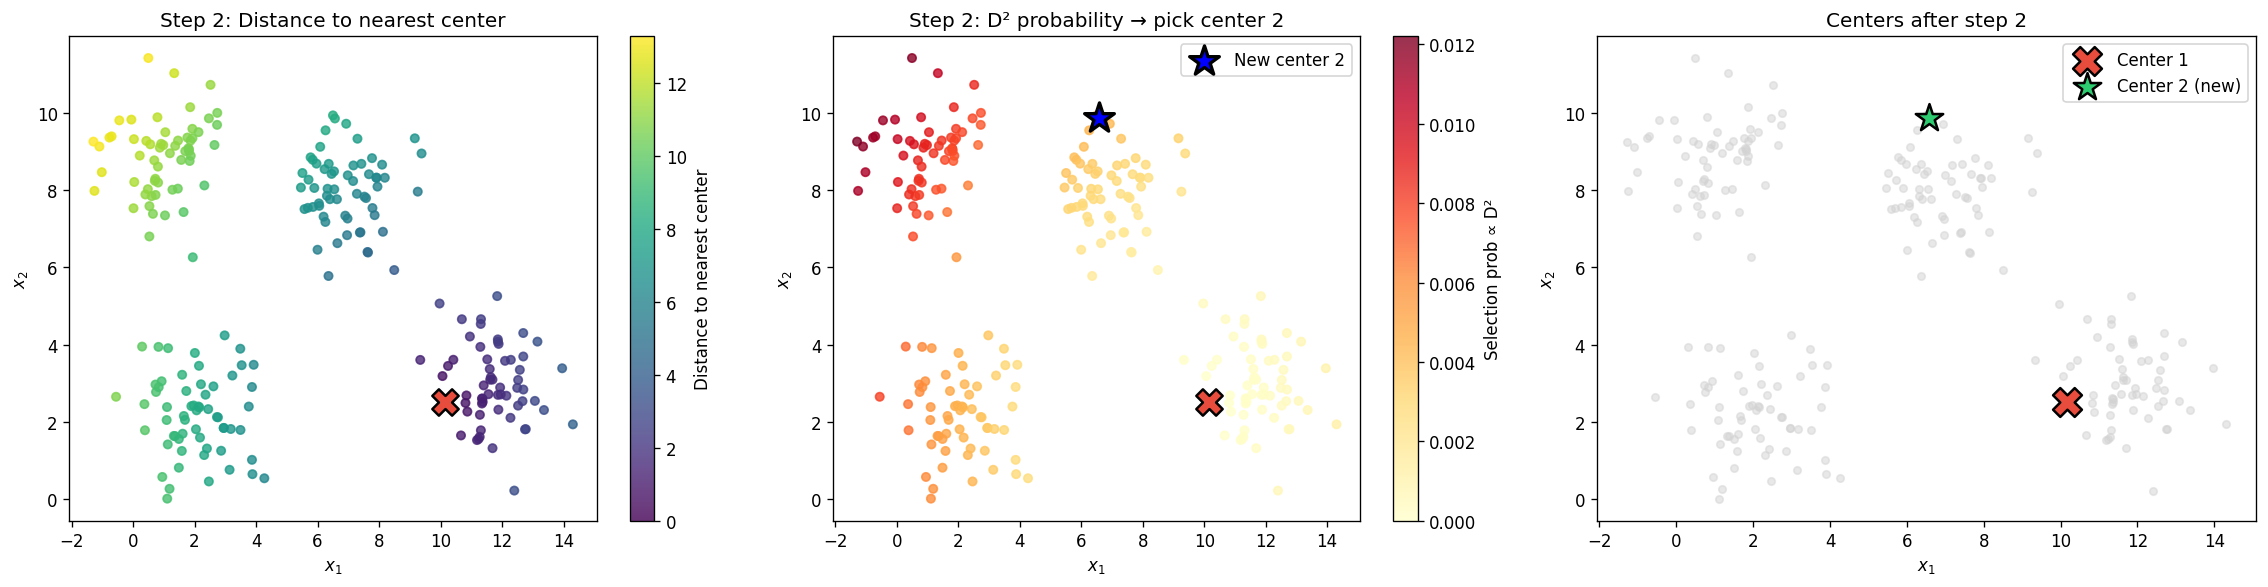


Step 3: D² sampling → pick center 3 = point 234  (-1.26, 7.98)


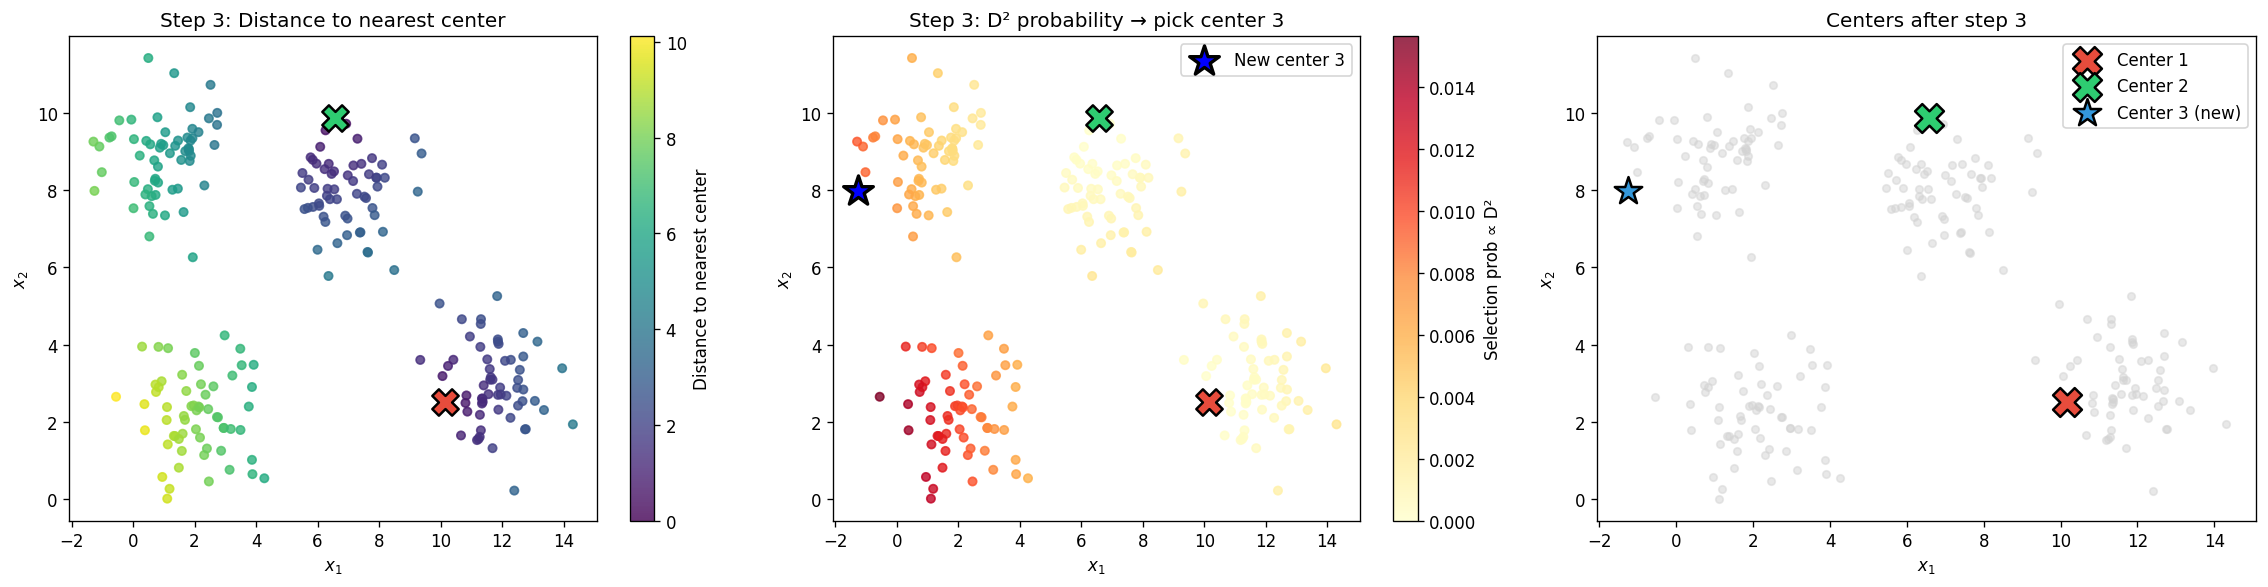


Step 4: D² sampling → pick center 4 = point 62  (1.61, 1.70)


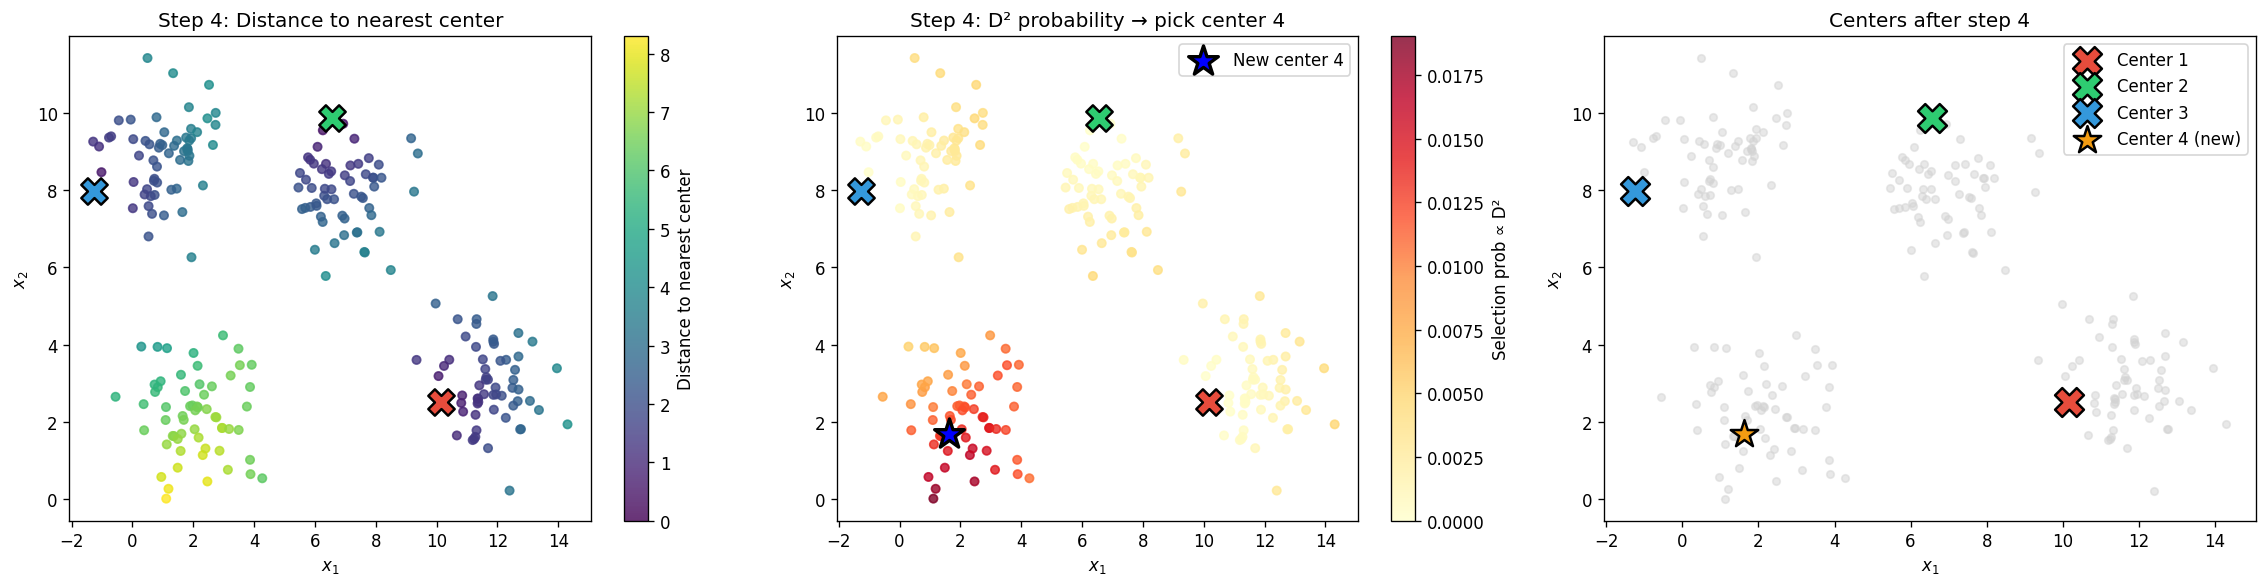

In [7]:
for step in range(2, K4 + 1):
    # Compute D(x)^2 = min distance² to any existing center
    all_dists = np.array([np.linalg.norm(X4 - X4[c], axis=1) for c in chosen_idx])  # (n_centers, N)
    min_dist = all_dists.min(axis=0)          # nearest center distance
    min_d2 = min_dist ** 2                     # D²
    probs = min_d2 / min_d2.sum()              # selection probability

    new_idx = rng_pp.choice(N4, p=probs)
    chosen_idx.append(new_idx)

    print(f"Step {step}: D² sampling → pick center {step} = point {new_idx}  "
          f"({X4[new_idx, 0]:.2f}, {X4[new_idx, 1]:.2f})")

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    # --- Panel 1: min distance to nearest center ---
    ax = axes[0]
    sc = ax.scatter(X4[:, 0], X4[:, 1], c=min_dist, cmap='viridis', s=25, alpha=0.8)
    for i, ci in enumerate(chosen_idx[:-1]):
        ax.scatter(*X4[ci], c=COLORS[i], s=250, marker='X',
                   edgecolors='black', linewidths=1.5, zorder=5)
    fig.colorbar(sc, ax=ax, label='Distance to nearest center')
    ax.set_title(f'Step {step}: Distance to nearest center', fontsize=12)
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

    # --- Panel 2: D² probability heatmap ---
    ax2 = axes[1]
    sc2 = ax2.scatter(X4[:, 0], X4[:, 1], c=probs, cmap='YlOrRd', s=25, alpha=0.8)
    for i, ci in enumerate(chosen_idx[:-1]):
        ax2.scatter(*X4[ci], c=COLORS[i], s=250, marker='X',
                    edgecolors='black', linewidths=1.5, zorder=5)
    ax2.scatter(*X4[new_idx], c='blue', s=350, marker='*',
               edgecolors='black', linewidths=2, zorder=6, label=f'New center {step}')
    fig.colorbar(sc2, ax=ax2, label='Selection prob ∝ D²')
    ax2.set_title(f'Step {step}: D² probability → pick center {step}', fontsize=12)
    ax2.legend(fontsize=10)
    ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$')

    # --- Panel 3: all chosen centers so far ---
    ax3 = axes[2]
    ax3.scatter(X4[:, 0], X4[:, 1], c='lightgray', s=20, alpha=0.5)
    for i, ci in enumerate(chosen_idx):
        marker = '*' if i == len(chosen_idx) - 1 else 'X'
        ax3.scatter(*X4[ci], c=COLORS[i], s=300, marker=marker,
                    edgecolors='black', linewidths=1.5, zorder=5,
                    label=f'Center {i+1}{" (new)" if i == len(chosen_idx)-1 else ""}')
    ax3.set_title(f'Centers after step {step}', fontsize=12)
    ax3.legend(fontsize=10)
    ax3.set_xlabel('$x_1$'); ax3.set_ylabel('$x_2$')

    plt.tight_layout()
    plt.show()
    print()

### Run k-means from the k-means++ centers

In [ ]:
centers_pp = X4[chosen_idx].copy()
for _ in range(30):
    d = np.linalg.norm(X4[:, None] - centers_pp[None], axis=2)
    labels_pp = d.argmin(axis=1)
    new_c = np.array([X4[labels_pp == k].mean(axis=0) for k in range(K4)])
    if np.allclose(centers_pp, new_c):
        break
    centers_pp = new_c

plt.figure(figsize=(7, 6))
for k in range(K4):
    mask = labels_pp == k
    plt.scatter(X4[mask, 0], X4[mask, 1], c=COLORS[k], s=25, alpha=0.6)
    plt.scatter(*centers_pp[k], c=COLORS[k], s=300, marker='X',
               edgecolors='black', linewidths=1.5, zorder=5)
plt.title('k-means++ → Final clustering result', fontsize=14)
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.show()

---
## 4. Elbow Method + Silhouette Score

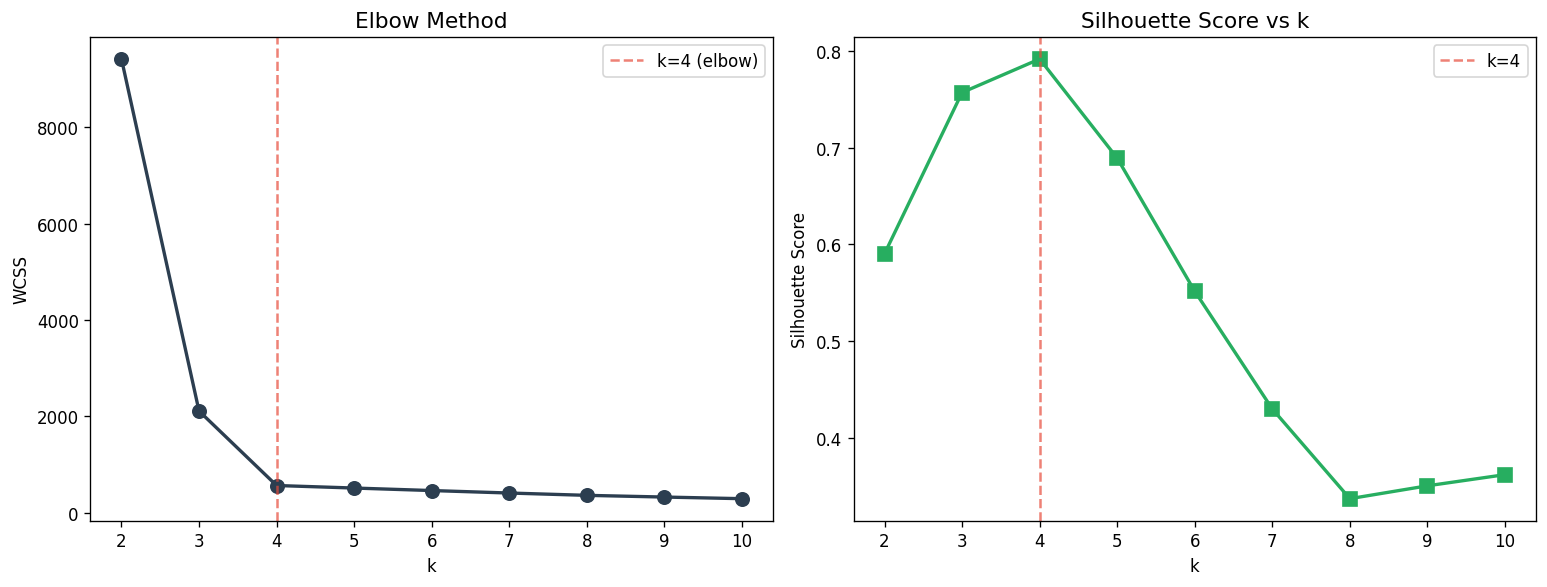

In [10]:
X_e, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)
K_range = range(2, 11)

wcss_list = []
sil_list = []
for k in K_range:
    km = KMeans(k, n_init=10, random_state=42).fit(X_e)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_e, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), wcss_list, 'o-', color='#2c3e50', lw=2, ms=8)
axes[0].axvline(4, color='#e74c3c', ls='--', alpha=0.7, label='k=4 (elbow)')
axes[0].set_xlabel('k'); axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method', fontsize=13); axes[0].legend()
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), sil_list, 's-', color='#27ae60', lw=2, ms=8)
axes[1].axvline(4, color='#e74c3c', ls='--', alpha=0.7, label='k=4')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k', fontsize=13); axes[1].legend()
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

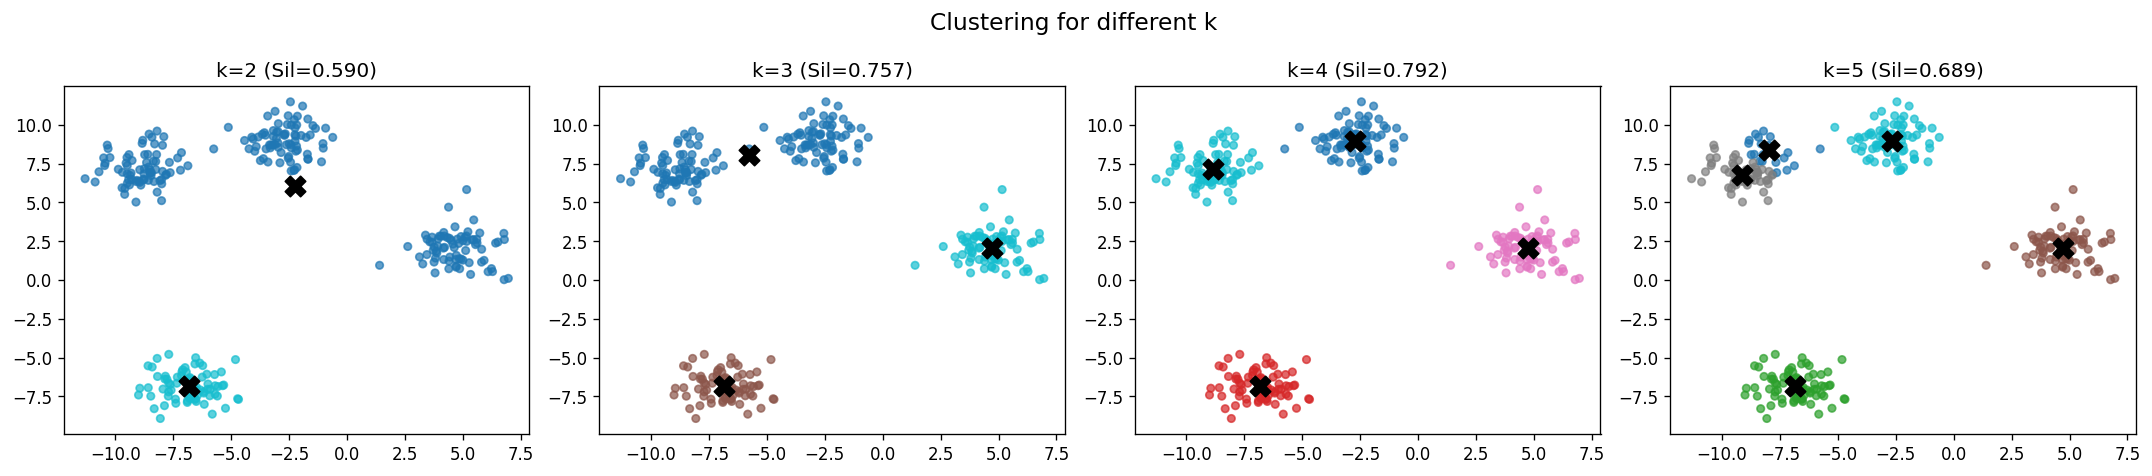

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, k in enumerate([2, 3, 4, 5]):
    km = KMeans(k, n_init=10, random_state=42).fit(X_e)
    ax = axes[i]
    ax.scatter(X_e[:, 0], X_e[:, 1], c=km.labels_, cmap='tab10', s=20, alpha=0.7)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='black', s=150, marker='X', zorder=5)
    sil = silhouette_score(X_e, km.labels_)
    ax.set_title(f'k={k} (Sil={sil:.3f})', fontsize=12)
plt.suptitle('Clustering for different k', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Clustering Metrics Comparison
Compare Purity, ARI, NMI, FMI, Silhouette across different clustering scenarios.

In [12]:
def purity_score(y_true, y_pred):
    cm = contingency_matrix(y_true, y_pred)
    return np.sum(np.max(cm, axis=0)) / len(y_true)

X_m, y_true_m = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
rng_m = np.random.RandomState(42)

scenarios = {
    'Perfect':        y_true_m.copy(),
    'k-means (K=3)':  KMeans(3, n_init=10, random_state=42).fit(X_m).labels_,
    'Over (K=9)':     KMeans(9, n_init=10, random_state=42).fit(X_m).labels_,
    'Under (K=2)':    KMeans(2, n_init=10, random_state=42).fit(X_m).labels_,
    'Random':         rng_m.randint(0, 3, len(X_m)),
    'Single cluster': np.zeros(len(X_m), dtype=int),
}

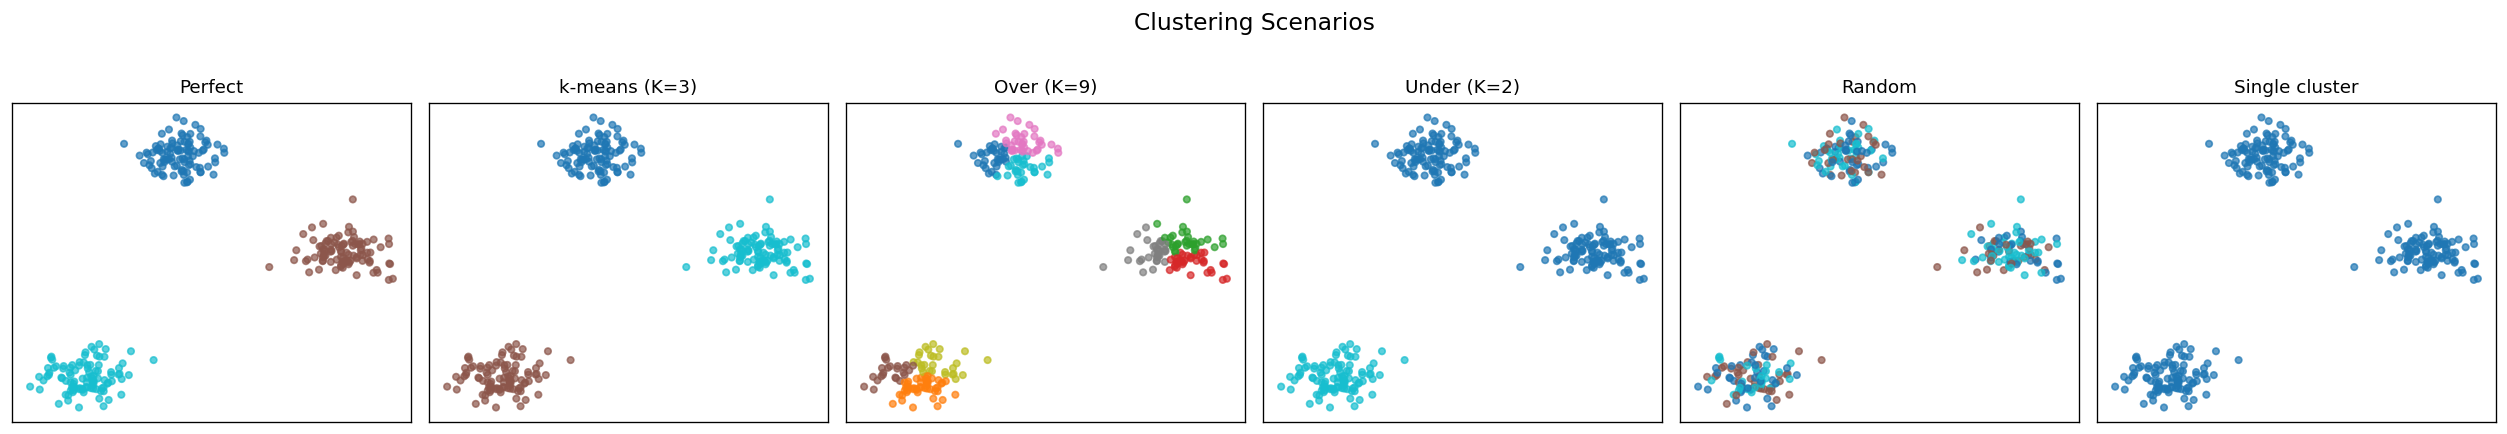

In [13]:
fig, axes = plt.subplots(1, len(scenarios), figsize=(3.5 * len(scenarios), 3.5))
for i, (name, labels) in enumerate(scenarios.items()):
    axes[i].scatter(X_m[:, 0], X_m[:, 1], c=labels, cmap='tab10', s=15, alpha=0.7)
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xticks([]); axes[i].set_yticks([])
plt.suptitle('Clustering Scenarios', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
metric_fns = {
    'Purity': lambda yt, yp: purity_score(yt, yp),
    'ARI':    lambda yt, yp: adjusted_rand_score(yt, yp),
    'NMI':    lambda yt, yp: normalized_mutual_info_score(yt, yp),
    'FMI':    lambda yt, yp: fowlkes_mallows_score(yt, yp),
}

names = list(scenarios.keys())
results = {m: [] for m in metric_fns}
results['Silhouette'] = []

for name in names:
    lab = scenarios[name]
    for mname, fn in metric_fns.items():
        results[mname].append(fn(y_true_m, lab))
    n_unique = len(set(lab))
    results['Silhouette'].append(silhouette_score(X_m, lab) if 2 <= n_unique < len(X_m) else float('nan'))

# Print table
header = f"{'Scenario':<18}" + ''.join(f"{m:<12}" for m in list(metric_fns) + ['Silhouette'])
print(header)
print('-' * len(header))
for i, name in enumerate(names):
    row = f"{name:<18}"
    for m in list(metric_fns) + ['Silhouette']:
        v = results[m][i]
        row += f"{v:<12.4f}" if not np.isnan(v) else f"{'N/A':<12}"
    print(row)

Scenario          Purity      ARI         NMI         FMI         Silhouette  
------------------------------------------------------------------------------
Perfect           1.0000      1.0000      1.0000      1.0000      0.8480      
k-means (K=3)     1.0000      1.0000      1.0000      1.0000      0.8480      
Over (K=9)        1.0000      0.4072      0.6703      0.5825      0.3713      
Under (K=2)       0.6667      0.5698      0.7337      0.7730      0.7049      
Random            0.4067      0.0104      0.0155      0.3386      -0.0428     
Single cluster    0.3333      0.0000      0.0000      0.5754      N/A         


In [ ]:
all_metrics = list(metric_fns) + ['Silhouette']
bar_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#95a5a6']

fig, axes = plt.subplots(1, len(all_metrics), figsize=(4 * len(all_metrics), 5))
for j, metric in enumerate(all_metrics):
    ax = axes[j]
    vals = results[metric]
    ax.barh(range(len(names)), vals, color=bar_colors[:len(names)], alpha=0.8)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    for k, v in enumerate(vals):
        if not np.isnan(v):
            ax.text(v + 0.02, k, f'{v:.2f}', va='center', fontsize=9)
    ax.set_xlim(-0.3 if metric == 'ARI' else -0.1, 1.15)

plt.suptitle('Clustering Metrics Comparison', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print('\nKey takeaways:')
print('  • Purity = 1.0 for over-clustering (K=9) — does NOT penalize over-clustering!')
print('  • ARI ≈ 0 for random labels — ARI is chance-corrected')
print('  • Silhouette is undefined for a single cluster (need at least 2)')